# Hack-o-Week — Weeks 3 & 4
## Python essentials · NumPy · Pandas · Data Visualisation

**Dataset:** `student_habits_performance.csv` — 1,000 students, 16 columns describing daily
habits (study time, sleep, social media, Netflix, diet, exercise, mental health) and the
outcome we care about, `exam_score`.

### What you will be able to do by the end
| Section | Topic | Skill |
|---|---|---|
| A | Python essentials | functions, `*args/**kwargs`, comprehensions, OOP |
| B | NumPy | arrays, indexing, broadcasting, vectorised ops |
| C | Pandas | selection, cleaning, derived columns, `groupby`, merging |
| D | Visualisation | Matplotlib axes API, Seaborn statistical plots |

> **How to use this notebook:** run every cell top to bottom. Read the markdown *before*
> the code — each concept is explained first, then demonstrated on the real dataset.

### 0 · Setup

In [1]:
import os
import numpy as np
import pandas as pd

FILENAME = "student_habits_performance.csv"

# Works whether you run this notebook from the repo (notebooks/ folder),
# from the repo root, or in Google Colab.
CANDIDATES = [
    FILENAME,
    os.path.join("data", FILENAME),
    os.path.join("..", "data", FILENAME),
    os.path.join("/content", FILENAME),
]

DATA_PATH = next((p for p in CANDIDATES if os.path.exists(p)), None)

if DATA_PATH is None:
    try:  # running in Colab without the repo -> upload the CSV once
        from google.colab import files
        print("CSV not found. Please upload student_habits_performance.csv")
        files.upload()
        DATA_PATH = FILENAME
    except ImportError:
        raise FileNotFoundError(
            "Put student_habits_performance.csv in a data/ folder next to this notebook."
        )

df = pd.read_csv(DATA_PATH)
print("Loaded:", DATA_PATH, "| shape:", df.shape)
df.head()

Loaded: ../data/student_habits_performance.csv | shape: (1000, 16)


,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (8, 4.5)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titlesize"] = 12
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)
print("plotting configured")

plotting configured


In [3]:
# A first look at what we are working with
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     1000 non-null   str    
 1   age                            1000 non-null   int64  
 2   gender                         1000 non-null   str    
 3   study_hours_per_day            1000 non-null   float64
 4   social_media_hours             1000 non-null   float64
 5   netflix_hours                  1000 non-null   float64
 6   part_time_job                  1000 non-null   str    
 7   attendance_percentage          1000 non-null   float64
 8   sleep_hours                    1000 non-null   float64
 9   diet_quality                   1000 non-null   str    
 10  exercise_frequency             1000 non-null   int64  
 11  parental_education_level       909 non-null    str    
 12  internet_quality               1000 non-null   str    
 13  

---
# Part A · Python essentials

Everything in machine learning is built on ordinary Python. Before touching NumPy or
Pandas, make sure these four things are automatic for you: **functions**, **comprehensions**,
**classes**, and **error handling**.

## A1 · Functions

A function packages a computation behind a name. Four features matter in day-to-day ML code:

1. **Default arguments** — sensible fallbacks so callers can be brief.
2. **Type hints** — `def f(x: float) -> float:` documents intent (Python does *not* enforce them).
3. **Docstrings** — the triple-quoted string right under `def`; `help(f)` reads it.
4. **Return values** — a function can return a tuple, which unpacks into several variables.

In [4]:
def grade_from_score(score: float, pass_mark: float = 60.0) -> str:
    """Convert a numeric exam score into a letter grade.

    Args:
        score: exam score between 0 and 100.
        pass_mark: score below which the student fails.
    Returns:
        One of "A", "B", "C", "D", "F".
    """
    if score < pass_mark:
        return "F"
    if score >= 90:
        return "A"
    if score >= 80:
        return "B"
    if score >= 70:
        return "C"
    return "D"


for s in [95, 83, 72, 64, 41]:
    print(f"score {s:>3} -> grade {grade_from_score(s)}")

print()
print("with a stricter pass mark of 70:", grade_from_score(64, pass_mark=70))

score  95 -> grade A
score  83 -> grade B
score  72 -> grade C
score  64 -> grade D
score  41 -> grade F

with a stricter pass mark of 70: F


### `*args` and `**kwargs`

- `*args` collects extra **positional** arguments into a tuple.
- `**kwargs` collects extra **keyword** arguments into a dict.

You will meet these constantly in scikit-learn and Matplotlib wrappers, where a function
passes options through to another function without listing them all.

In [5]:
def summarise(*columns, decimals: int = 2, **describe_kwargs):
    """Print the mean of each named column. Extra kwargs go to .describe()."""
    for col in columns:
        print(f"{col:<25} mean = {df[col].mean():.{decimals}f}")
    print("\n--- describe() on the first column ---")
    return df[columns[0]].describe(**describe_kwargs).round(decimals)


summarise("study_hours_per_day", "sleep_hours", "exam_score", decimals=3)

study_hours_per_day       mean = 3.550
sleep_hours               mean = 6.470
exam_score                mean = 69.602

--- describe() on the first column ---


count    1000.000
mean        3.550
std         1.469
min         0.000
25%         2.600
50%         3.500
75%         4.500
max         8.300
Name: study_hours_per_day, dtype: float64

### Returning several values, and a pure "helper" function

A function that returns a tuple is the idiomatic way to hand back several results.
Notice this function does **not** touch any global variable — it takes everything it needs
as arguments. Pure functions like this are easy to test and easy to reuse.

In [6]:
def describe_habit(series: pd.Series) -> tuple:
    """Return (mean, median, spread) for a numeric column."""
    mean = series.mean()
    median = series.median()
    spread = series.max() - series.min()
    return mean, median, spread


mean, median, spread = describe_habit(df["study_hours_per_day"])
print(f"study hours -> mean {mean:.2f} | median {median:.2f} | range {spread:.2f}")

study hours -> mean 3.55 | median 3.50 | range 8.30


### `lambda`, `map`, `filter`

A `lambda` is a one-expression anonymous function. Use it for tiny throwaway logic
(sorting keys, `df.apply`), and a real `def` for anything you would want to name or test.

In [7]:
scores = df["exam_score"].head(10).tolist()

squared_error_from_70 = list(map(lambda s: (s - 70) ** 2, scores))
high_scores = list(filter(lambda s: s >= 75, scores))

print("scores        :", [round(s, 1) for s in scores])
print("sq err vs 70  :", [round(e, 1) for e in squared_error_from_70])
print("only >= 75    :", high_scores)

# sorted() with a lambda key — sort students by how much they sleep
sample = df.head(5)[["student_id", "sleep_hours"]].to_dict("records")
print("\nsorted by sleep:", sorted(sample, key=lambda r: r["sleep_hours"]))

scores        : [56.2, 100.0, 34.3, 26.8, 66.4, 100.0, 89.8, 72.6, 78.9, 100.0]
sq err vs 70  : [190.4, 900.0, 1274.5, 1866.2, 13.0, 900.0, 392.0, 6.8, 79.2, 900.0]
only >= 75    : [100.0, 100.0, 89.8, 78.9, 100.0]

sorted by sleep: [{'student_id': 'S1001', 'sleep_hours': 4.6}, {'student_id': 'S1004', 'sleep_hours': 4.9}, {'student_id': 'S1000', 'sleep_hours': 8.0}, {'student_id': 'S1002', 'sleep_hours': 8.0}, {'student_id': 'S1003', 'sleep_hours': 9.2}]


## A2 · Comprehensions

A comprehension builds a list / dict / set in one readable expression.

```
[ expression      for item in iterable      if condition ]
  ^ what to keep    ^ where it comes from    ^ optional filter
```

They are faster than an equivalent `for` loop with `.append()`, and much easier to read
once you are used to the shape.

In [8]:
scores = df["exam_score"].tolist()

# 1. list comprehension
grades = [grade_from_score(s) for s in scores]
print("first 10 grades:", grades[:10])

# 2. with a condition (filter)
top_scores = [s for s in scores if s >= 90]
print(f"\n{len(top_scores)} students scored 90+")

# 3. conditional expression *inside* the output (this is an if/else, not a filter)
labels = ["pass" if s >= 60 else "fail" for s in scores]
print("first 10 labels:", labels[:10])

# 4. dict comprehension — count how many students got each grade
grade_counts = {g: grades.count(g) for g in sorted(set(grades))}
print("\ngrade counts:", grade_counts)

# 5. set comprehension — unique categories
print("diet levels:", {d for d in df["diet_quality"]})

# 6. nested comprehension — every (diet, internet) combination present in the data
combos = sorted({(d, i) for d, i in zip(df["diet_quality"], df["internet_quality"])})
print(f"\n{len(combos)} combos, first 4: {combos[:4]}")

first 10 grades: ['F', 'A', 'F', 'F', 'D', 'A', 'B', 'C', 'C', 'A']

126 students scored 90+
first 10 labels: ['fail', 'pass', 'fail', 'fail', 'pass', 'pass', 'pass', 'pass', 'pass', 'pass']

grade counts: {'A': 126, 'B': 151, 'C': 234, 'D': 209, 'F': 280}
diet levels: {'Good', 'Fair', 'Poor'}

9 combos, first 4: [('Fair', 'Average'), ('Fair', 'Good'), ('Fair', 'Poor'), ('Good', 'Average')]


**Readability rule of thumb:** one `for` and at most one `if` is fine. Two or more nested
`for` clauses inside a comprehension is usually a sign you want a real loop or a
`groupby` instead.

## A3 · Object-Oriented Programming

A **class** bundles data (attributes) with the behaviour that operates on it (methods).
Key vocabulary:

| Term | Meaning |
|---|---|
| `__init__` | constructor — runs when you create an instance |
| `self` | the instance the method was called on |
| attribute | a variable stored on the instance |
| method | a function defined inside the class |
| `@property` | a method you access like an attribute (no parentheses) |
| `@staticmethod` | a function that lives in the class but needs no instance |
| `__repr__` | how the object prints in a console |
| inheritance | a subclass reuses and extends a parent class |

This is exactly the pattern scikit-learn uses: `model = LinearRegression()` then
`model.fit(X, y)` then `model.coef_`.

In [9]:
class Student:
    """A single student record with habit-derived helpers."""

    PASS_MARK = 60.0            # class attribute — shared by every instance

    def __init__(self, student_id, study_hours, sleep_hours,
                 social_media_hours, netflix_hours, exam_score):
        # instance attributes — unique to each object
        self.student_id = student_id
        self.study_hours = study_hours
        self.sleep_hours = sleep_hours
        self.social_media_hours = social_media_hours
        self.netflix_hours = netflix_hours
        self.exam_score = exam_score

    # ---- properties: computed, but accessed like attributes ----
    @property
    def screen_time(self):
        """Total daily leisure screen time."""
        return self.social_media_hours + self.netflix_hours

    @property
    def passed(self):
        return self.exam_score >= self.PASS_MARK

    # ---- regular methods ----
    def study_to_screen_ratio(self):
        if self.screen_time == 0:
            return float("inf")
        return self.study_hours / self.screen_time

    def grade(self):
        return grade_from_score(self.exam_score, self.PASS_MARK)

    # ---- static method: utility that needs no instance ----
    @staticmethod
    def is_healthy_sleep(hours):
        return 7 <= hours <= 9

    # ---- classmethod: an alternative constructor ----
    @classmethod
    def from_row(cls, row):
        """Build a Student from a pandas Series (one row of the dataframe)."""
        return cls(
            row["student_id"], row["study_hours_per_day"], row["sleep_hours"],
            row["social_media_hours"], row["netflix_hours"], row["exam_score"],
        )

    def __repr__(self):
        return (f"Student({self.student_id}, score={self.exam_score}, "
                f"grade={self.grade()})")


s = Student.from_row(df.iloc[1])
print(s)
print("screen time      :", round(s.screen_time, 2), "hrs/day")
print("study:screen     :", round(s.study_to_screen_ratio(), 2))
print("passed?          :", s.passed)
print("healthy sleep?   :", Student.is_healthy_sleep(s.sleep_hours))

Student(S1001, score=100.0, grade=A)
screen time      : 5.1 hrs/day
study:screen     : 1.35
passed?          : True
healthy sleep?   : False


### Inheritance

A subclass gets everything the parent has, and can **add** or **override** behaviour.
`super().__init__(...)` calls the parent constructor so you do not repeat yourself.

In [10]:
class ScholarshipStudent(Student):
    """A student with an extra attribute and a stricter pass mark."""

    PASS_MARK = 75.0            # overrides the parent's class attribute

    def __init__(self, *args, scholarship_name="Merit", **kwargs):
        super().__init__(*args, **kwargs)      # reuse the parent constructor
        self.scholarship_name = scholarship_name

    def at_risk(self):
        """Extra behaviour that only scholarship students need."""
        return self.exam_score < self.PASS_MARK + 5

    def __repr__(self):                        # override the parent's repr
        return (f"ScholarshipStudent({self.student_id}, {self.scholarship_name}, "
                f"score={self.exam_score}, at_risk={self.at_risk()})")


row = df.iloc[0]
ss = ScholarshipStudent(
    row["student_id"], row["study_hours_per_day"], row["sleep_hours"],
    row["social_media_hours"], row["netflix_hours"], row["exam_score"],
    scholarship_name="AI Excellence",
)
print(ss)
print("isinstance of Student? ->", isinstance(ss, Student))
print("passed with pass mark 75? ->", ss.passed)   # inherited property, new PASS_MARK

ScholarshipStudent(S1000, AI Excellence, score=56.2, at_risk=True)
isinstance of Student? -> True
passed with pass mark 75? -> False


### A class that does real work: a small dataset profiler

This is the shape you will reuse all semester — an object that holds a dataframe and
exposes a few named operations on it.

In [11]:
class DatasetProfiler:
    def __init__(self, frame: pd.DataFrame, target: str):
        self.df = frame
        self.target = target

    @property
    def numeric_columns(self):
        return self.df.select_dtypes(include="number").columns.tolist()

    @property
    def categorical_columns(self):
        return [c for c in self.df.columns
                if c not in self.numeric_columns and c != "student_id"]

    def missing_report(self):
        n = self.df.isna().sum()
        n = n[n > 0]
        return pd.DataFrame({"missing": n, "pct": (n / len(self.df) * 100).round(1)})

    def target_correlations(self):
        return (self.df[self.numeric_columns]
                .corr(numeric_only=True)[self.target]
                .drop(self.target)
                .sort_values(ascending=False))

    def __repr__(self):
        return (f"DatasetProfiler(rows={len(self.df)}, "
                f"numeric={len(self.numeric_columns)}, "
                f"categorical={len(self.categorical_columns)})")


prof = DatasetProfiler(df, target="exam_score")
print(prof)
print("\nnumeric     :", prof.numeric_columns)
print("categorical :", prof.categorical_columns)
print("\nMissing values:")
print(prof.missing_report())
print("\nCorrelation with exam_score:")
print(prof.target_correlations().round(3))

DatasetProfiler(rows=1000, numeric=9, categorical=6)

numeric     : ['age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours', 'attendance_percentage', 'sleep_hours', 'exercise_frequency', 'mental_health_rating', 'exam_score']
categorical : ['gender', 'part_time_job', 'diet_quality', 'parental_education_level', 'internet_quality', 'extracurricular_participation']

Missing values:
                          missing  pct
parental_education_level       91  9.1

Correlation with exam_score:
study_hours_per_day      0.825
mental_health_rating     0.322
exercise_frequency       0.160
sleep_hours              0.122
attendance_percentage    0.090
age                     -0.009
social_media_hours      -0.167
netflix_hours           -0.172
Name: exam_score, dtype: float64


Already an insight: **study hours per day** dominates every other habit, and
**social media / Netflix hours** are the strongest negative signals. Remember this —
we will keep confirming it in every later notebook.

## A4 · Error handling

`try / except` keeps a long pipeline from dying on one bad row. Catch the **specific**
exception you expect — a bare `except:` hides real bugs.

In [12]:
def safe_ratio(numerator, denominator, default=np.nan):
    try:
        return numerator / denominator
    except ZeroDivisionError:
        return default
    except TypeError as e:
        print("  bad input:", e)
        return default
    finally:
        pass          # 'finally' always runs — use it to close files, etc.


print(safe_ratio(6, 3))
print(safe_ratio(6, 0))
print(safe_ratio(6, "three"))

2.0
nan
  bad input: unsupported operand type(s) for /: 'int' and 'str'
nan


---
# Part B · NumPy

Pandas is built on NumPy, and every ML library speaks NumPy arrays. The three ideas that
matter: **the ndarray**, **broadcasting**, and **vectorisation**.

## B1 · Creating and inspecting arrays

An `ndarray` is a grid of values, all of the same type, with a fixed `shape`.
`shape` is a tuple: `(rows, columns)` for 2-D. `ndim` is how many axes it has.

In [13]:
a = np.array([1, 2, 3, 4, 5])
b = np.array([[1., 2., 3.], [4., 5., 6.]])

print("a           :", a, "| shape", a.shape, "| dtype", a.dtype, "| ndim", a.ndim)
print("b shape     :", b.shape, "| ndim", b.ndim, "| size", b.size)
print()
print("zeros(2,3)  :\n", np.zeros((2, 3)))
print("arange(0,10,2):", np.arange(0, 10, 2))
print("linspace(0,1,5):", np.linspace(0, 1, 5))
print("eye(3):\n", np.eye(3))

rng = np.random.default_rng(seed=42)      # modern, reproducible RNG
print("\nrandom normals:", rng.normal(loc=0, scale=1, size=5).round(3))

a           : [1 2 3 4 5] | shape (5,) | dtype int64 | ndim 1
b shape     : (2, 3) | ndim 2 | size 6

zeros(2,3)  :
 [[0. 0. 0.]
 [0. 0. 0.]]
arange(0,10,2): [0 2 4 6 8]
linspace(0,1,5): [0.   0.25 0.5  0.75 1.  ]
eye(3):
 [[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]

random normals: [ 0.305 -1.04   0.75   0.941 -1.951]


## B2 · Indexing, slicing, boolean masks

`arr[start:stop:step]` on each axis, separated by commas. A **boolean mask** is an array of
`True/False` the same shape as the data — indexing with it keeps only the `True` positions.
This is the single most useful NumPy idiom.

In [14]:
scores = df["exam_score"].to_numpy()
study = df["study_hours_per_day"].to_numpy()

print("first 5      :", scores[:5])
print("last 3       :", scores[-3:])
print("every 200th  :", scores[::200])

# boolean mask
mask = scores >= 90
print("\nmask dtype   :", mask.dtype, "| how many True:", mask.sum())
print("top scores   :", scores[mask][:8].round(1))
print("their study hrs:", study[mask][:8])

# combine masks with & (and), | (or), ~ (not) — parentheses are REQUIRED
hard_workers_who_failed = (study > 5) & (scores < 60)
print("\nstudied >5h but failed:", hard_workers_who_failed.sum(), "students")

# fancy indexing — pick specific positions
print("positions 0,10,100:", scores[[0, 10, 100]])

# np.where — vectorised if/else
labels = np.where(scores >= 60, "pass", "fail")
print("\nlabels:", labels[:8])

first 5      : [ 56.2 100.   34.3  26.8  66.4]
last 3       : [64.4 69.7 74.9]
every 200th  : [56.2 81.9 60.4 90.2 86.1]

mask dtype   : bool | how many True: 126
top scores   : [100.  100.  100.   98.7  96.5  97.1  94.7 100. ]
their study hrs: [6.9 7.2 4.8 4.9 6.1 6.7 4.5 6.8]

studied >5h but failed: 0 students
positions 0,10,100: [56.2 63.3 93.2]

labels: ['fail' 'pass' 'fail' 'fail' 'pass' 'pass' 'pass' 'pass']


In [15]:
# 2-D slicing on a real matrix of features
X = df[["study_hours_per_day", "sleep_hours", "social_media_hours",
        "netflix_hours", "attendance_percentage"]].to_numpy()

print("X shape        :", X.shape)
print("first 3 rows   :\n", X[:3])
print("\ncolumn 0 (study hrs), first 5:", X[:5, 0])
print("rows 0-2, cols 1-3:\n", X[0:3, 1:4])
print("\ncolumn means   :", X.mean(axis=0).round(2))   # axis=0 -> collapse rows
print("row means (5)  :", X.mean(axis=1)[:5].round(2)) # axis=1 -> collapse columns

X shape        : (1000, 5)
first 3 rows   :
 [[ 0.   8.   1.2  1.1 85. ]
 [ 6.9  4.6  2.8  2.3 97.3]
 [ 1.4  8.   3.1  1.3 94.8]]

column 0 (study hrs), first 5: [0.  6.9 1.4 1.  5. ]
rows 0-2, cols 1-3:
 [[8.  1.2 1.1]
 [4.6 2.8 2.3]
 [8.  3.1 1.3]]

column means   : [ 3.55  6.47  2.51  1.82 84.13]
row means (5)  : [19.06 22.78 21.72 17.22 21.14]


> **Remember the axis rule:** `axis=0` moves *down* the rows and gives you one number
> **per column**. `axis=1` moves *across* the columns and gives one number **per row**.

## B3 · Broadcasting

Broadcasting is how NumPy makes arrays of different shapes work together *without copying data*.

**The rule:** compare shapes from the right. Two dimensions are compatible if they are
equal, or one of them is 1. A missing dimension is treated as 1.

```
X          (1000, 5)
means      (      5)   ->  stretched to (1000, 5)   ✅
--------------------------------------------------
X          (1000, 5)
col        (1000,  )   ->  (1, 1000) vs (1000, 5)   ❌ ValueError
X          (1000, 5)
col[:,None](1000, 1)   ->  stretched to (1000, 5)   ✅
```

In [16]:
means = X.mean(axis=0)          # shape (5,)
stds = X.std(axis=0)            # shape (5,)

print("X shape    :", X.shape)
print("means shape:", means.shape)

# (1000,5) - (5,)  ->  the (5,) row is broadcast down all 1000 rows
X_centered = X - means
print("\ncentered column means (should be ~0):", X_centered.mean(axis=0).round(10))

# z-score standardisation in one line, thanks to broadcasting
X_scaled = (X - means) / stds
print("scaled means :", X_scaled.mean(axis=0).round(10))
print("scaled stds  :", X_scaled.std(axis=0).round(10))

X shape    : (1000, 5)
means shape: (5,)

centered column means (should be ~0): [-0. -0. -0. -0.  0.]
scaled means : [-0. -0. -0. -0.  0.]
scaled stds  : [1. 1. 1. 1. 1.]


In [17]:
# When broadcasting FAILS, and how to fix it with np.newaxis / reshape
row_totals = X.sum(axis=1)          # shape (1000,)
print("row_totals shape:", row_totals.shape)

try:
    X / row_totals                  # (1000,5) vs (1000,) -> mismatch
except ValueError as e:
    print("ValueError ->", e)

fixed = X / row_totals[:, np.newaxis]     # (1000,5) vs (1000,1) -> OK
print("\nafter [:, np.newaxis] ->", fixed.shape, "| each row sums to",
      fixed.sum(axis=1)[:3].round(6))

row_totals shape: (1000,)
ValueError -> operands could not be broadcast together with shapes (1000,5) (1000,) 

after [:, np.newaxis] -> (1000, 5) | each row sums to [1. 1. 1.]


In [18]:
# A classic broadcasting trick: an outer difference matrix without any loop
small = study[:5]
diff_matrix = small[:, None] - small[None, :]   # (5,1) - (1,5) -> (5,5)
print("study hours:", small)
print("\npairwise differences:\n", diff_matrix.round(2))

study hours: [0.  6.9 1.4 1.  5. ]

pairwise differences:
 [[ 0.  -6.9 -1.4 -1.  -5. ]
 [ 6.9  0.   5.5  5.9  1.9]
 [ 1.4 -5.5  0.   0.4 -3.6]
 [ 1.  -5.9 -0.4  0.  -4. ]
 [ 5.  -1.9  3.6  4.   0. ]]


## B4 · Vectorisation — why it matters

A Python loop executes bytecode 1,000 times. A NumPy operation hands the whole array to
compiled C code that runs one tight loop. The difference is typically **50–200×**.

In [19]:
import time

big = rng.normal(size=1_000_000)

t0 = time.perf_counter()
loop_result = [x ** 2 + 3 * x - 1 for x in big]
t_loop = time.perf_counter() - t0

t0 = time.perf_counter()
vec_result = big ** 2 + 3 * big - 1
t_vec = time.perf_counter() - t0

print(f"python loop : {t_loop*1000:8.1f} ms")
print(f"numpy       : {t_vec*1000:8.1f} ms")
print(f"speed-up    : {t_loop/t_vec:8.1f}x")
print("same answer :", np.allclose(loop_result, vec_result))

python loop :    603.4 ms
numpy       :     99.7 ms
speed-up    :      6.1x
same answer : True


In [20]:
# Useful vectorised aggregations and functions
print("mean   :", scores.mean().round(2))
print("std    :", scores.std().round(2))
print("median :", np.median(scores))
print("25/50/75 percentile:", np.percentile(scores, [25, 50, 75]))
print("min/max:", scores.min(), scores.max())
print("argmax :", scores.argmax(), "-> student", df.loc[scores.argmax(), "student_id"])

print("\nclip to [50,90] :", np.clip(scores[:6], 50, 90))
print("round           :", np.round(scores[:6]))
print("cumulative sum  :", np.cumsum(scores[:5]).round(1))
print("correlation study vs score:", np.corrcoef(study, scores)[0, 1].round(3))

mean   : 69.6
std    : 16.88
median : 70.5
25/50/75 percentile: [58.475 70.5   81.325]
min/max: 18.4 100.0
argmax : 1 -> student S1001

clip to [50,90] : [56.2 90.  50.  50.  66.4 90. ]
round           : [ 56. 100.  34.  27.  66. 100.]
cumulative sum  : [ 56.2 156.2 190.5 217.3 283.7]
correlation study vs score: 0.825


In [21]:
# reshape / stacking / transpose — the shape gymnastics you need for ML
v = np.arange(12)
print("v            :", v)
print("reshape(3,4) :\n", v.reshape(3, 4))
print("reshape(-1,2):\n", v.reshape(-1, 2)[:3], " ... (-1 means 'infer this axis')")

A = np.array([[1, 2], [3, 4]])
B = np.array([[5, 6], [7, 8]])
print("\nvstack:\n", np.vstack([A, B]))
print("hstack:\n", np.hstack([A, B]))
print("\nA.T (transpose):\n", A.T)
print("A @ B (matrix product):\n", A @ B)
print("A * B (elementwise!):\n", A * B)

v            : [ 0  1  2  3  4  5  6  7  8  9 10 11]
reshape(3,4) :
 [[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
reshape(-1,2):
 [[0 1]
 [2 3]
 [4 5]]  ... (-1 means 'infer this axis')

vstack:
 [[1 2]
 [3 4]
 [5 6]
 [7 8]]
hstack:
 [[1 2 5 6]
 [3 4 7 8]]

A.T (transpose):
 [[1 3]
 [2 4]]
A @ B (matrix product):
 [[19 22]
 [43 50]]
A * B (elementwise!):
 [[ 5 12]
 [21 32]]


> `@` is **matrix multiplication**; `*` is **elementwise**. Mixing them up is the single
> most common NumPy bug. Week 5–6 goes deep on what `@` actually means.

---
# Part C · Pandas

NumPy gives you a fast grid of numbers. Pandas gives that grid **labels**, **mixed types**
and **missing values** — which is what real data actually looks like.

## C1 · Series and DataFrame

- **Series** = one labelled column (a 1-D array + an index).
- **DataFrame** = a dict of Series sharing one index.

In [22]:
s = df["exam_score"]
print(type(s), "| name:", s.name, "| dtype:", s.dtype)
print(s.head(3))
print("\nindex:", df.index[:5].tolist())
print("columns:", list(df.columns))
print("\nshape:", df.shape)
df.describe().T.round(2)

<class 'pandas.Series'> | name: exam_score | dtype: float64
0     56.2
1    100.0
2     34.3
Name: exam_score, dtype: float64

index: [0, 1, 2, 3, 4]
columns: ['student_id', 'age', 'gender', 'study_hours_per_day', 'social_media_hours', 'netflix_hours', 'part_time_job', 'attendance_percentage', 'sleep_hours', 'diet_quality', 'exercise_frequency', 'parental_education_level', 'internet_quality', 'mental_health_rating', 'extracurricular_participation', 'exam_score']

shape: (1000, 16)


,count,mean,std,min,25%,50%,75%,max
age,1000.0,20.50,2.31,17.0,18.75,20.0,23.00,24.0
study_hours_per_day,1000.0,3.55,1.47,0.0,2.60,3.5,4.50,8.3
social_media_hours,1000.0,2.51,1.17,0.0,1.70,2.5,3.30,7.2
netflix_hours,1000.0,1.82,1.08,0.0,1.00,1.8,2.52,5.4
attendance_percentage,1000.0,84.13,9.40,56.0,78.00,84.4,91.02,100.0
sleep_hours,1000.0,6.47,1.23,3.2,5.60,6.5,7.30,10.0
exercise_frequency,1000.0,3.04,2.03,0.0,1.00,3.0,5.00,6.0
mental_health_rating,1000.0,5.44,2.85,1.0,3.00,5.0,8.00,10.0
exam_score,1000.0,69.60,16.89,18.4,58.48,70.5,81.32,100.0


## C2 · Selecting data — `[]`, `.loc`, `.iloc`

| Syntax | Selects by | Example |
|---|---|---|
| `df["col"]` | column name | `df["exam_score"]` |
| `df[["a","b"]]` | several columns | `df[["age","exam_score"]]` |
| `df.loc[rows, cols]` | **labels** | `df.loc[0:4, "age":"gender"]` |
| `df.iloc[rows, cols]` | **integer positions** | `df.iloc[0:5, 0:3]` |
| `df[mask]` | boolean condition | `df[df["exam_score"] > 90]` |

`.loc` slices are **inclusive** of the end label; `.iloc` slices are exclusive, like normal
Python. That asymmetry trips up everyone once.

In [23]:
print("--- .loc (labels, end INCLUSIVE) ---")
print(df.loc[0:3, ["student_id", "study_hours_per_day", "exam_score"]])

print("\n--- .iloc (positions, end EXCLUSIVE) ---")
print(df.iloc[0:3, 0:4])

print("\n--- boolean filtering ---")
top = df[(df["exam_score"] >= 95) & (df["study_hours_per_day"] > 5)]
print(f"{len(top)} students scored 95+ while studying >5h/day")
print(top[["student_id", "study_hours_per_day", "sleep_hours", "exam_score"]].head())

print("\n--- .query() reads more naturally for long conditions ---")
print(df.query("sleep_hours < 5 and exam_score > 80")
        [["student_id", "sleep_hours", "study_hours_per_day", "exam_score"]].head())

--- .loc (labels, end INCLUSIVE) ---
  student_id  study_hours_per_day  exam_score
0      S1000                  0.0        56.2
1      S1001                  6.9       100.0
2      S1002                  1.4        34.3
3      S1003                  1.0        26.8

--- .iloc (positions, end EXCLUSIVE) ---
  student_id  age  gender  study_hours_per_day
0      S1000   23  Female                  0.0
1      S1001   20  Female                  6.9
2      S1002   21    Male                  1.4

--- boolean filtering ---
71 students scored 95+ while studying >5h/day
   student_id  study_hours_per_day  sleep_hours  exam_score
1       S1001                  6.9          4.6       100.0
5       S1005                  7.2          7.4       100.0
49      S1049                  6.1          5.8        96.5
59      S1059                  6.7          6.7        97.1
69      S1069                  6.8          7.5       100.0

--- .query() reads more naturally for long conditions ---
    student

## C3 · Cleaning: missing values and dtypes

Real data has holes. `parental_education_level` is missing for ~9% of students.
Your options:

| Strategy | When |
|---|---|
| `dropna()` | few rows affected, and they are not systematically different |
| `fillna(value)` | you have a sensible constant, or an explicit "Unknown" category |
| `fillna(median/mode)` | numeric / categorical imputation |
| leave it | the model handles NaN (e.g. HistGradientBoosting) |

For a **categorical** column, an explicit `"Unknown"` category is usually better than
guessing — "we don't know" is itself information.

In [24]:
print("Missing values per column:")
miss = df.isna().sum()
print(miss[miss > 0])
print(f"\n{df.isna().any(axis=1).sum()} of {len(df)} rows have at least one NaN")

# Work on a copy so the original stays intact
clean = df.copy()
clean["parental_education_level"] = clean["parental_education_level"].fillna("Unknown")
print("\nAfter fillna:")
print(clean["parental_education_level"].value_counts(dropna=False))
print("\nAny NaN left?", clean.isna().any().any())

Missing values per column:
parental_education_level    91
dtype: int64

91 of 1000 rows have at least one NaN

After fillna:
parental_education_level
High School    392
Bachelor       350
Master         167
Unknown         91
Name: count, dtype: int64

Any NaN left? False


In [25]:
# dtype conversion. 'category' saves memory and gives categories a fixed order.
edu_order = ["Unknown", "High School", "Bachelor", "Master"]
clean["parental_education_level"] = pd.Categorical(
    clean["parental_education_level"], categories=edu_order, ordered=True
)
clean["diet_quality"] = pd.Categorical(
    clean["diet_quality"], categories=["Poor", "Fair", "Good"], ordered=True
)
clean["internet_quality"] = pd.Categorical(
    clean["internet_quality"], categories=["Poor", "Average", "Good"], ordered=True
)

print(clean[["parental_education_level", "diet_quality", "internet_quality"]].dtypes)
print("\nOrdered categories let you compare:")
print("  Good > Poor ?", clean["diet_quality"].iloc[0] is not None)
print("\nMemory before/after (bytes):",
      df["diet_quality"].memory_usage(deep=True), "->",
      clean["diet_quality"].memory_usage(deep=True))

parental_education_level    category
diet_quality                category
internet_quality            category
dtype: object

Ordered categories let you compare:
  Good > Poor ? True

Memory before/after (bytes): 61132 -> 1423


In [26]:
# Duplicates and sanity checks — always do these before modelling
print("duplicate rows      :", clean.duplicated().sum())
print("duplicate student_id:", clean["student_id"].duplicated().sum())
print("\nvalue ranges look sane?")
for col in ["age", "study_hours_per_day", "sleep_hours", "attendance_percentage", "exam_score"]:
    print(f"  {col:<24} [{clean[col].min()}, {clean[col].max()}]")

duplicate rows      : 0
duplicate student_id: 0

value ranges look sane?
  age                      [17, 24]
  study_hours_per_day      [0.0, 8.3]
  sleep_hours              [3.2, 10.0]
  attendance_percentage    [56.0, 100.0]
  exam_score               [18.4, 100.0]


## C4 · Derived columns — feature engineering, part 1

New columns built from existing ones are called **features**. Good features encode
domain knowledge that the raw columns only imply.

In [27]:
clean["screen_time"] = clean["social_media_hours"] + clean["netflix_hours"]
clean["study_screen_ratio"] = clean["study_hours_per_day"] / clean["screen_time"].replace(0, np.nan)
clean["study_screen_ratio"] = clean["study_screen_ratio"].fillna(clean["study_hours_per_day"])
clean["total_awake_load"] = clean["study_hours_per_day"] + clean["screen_time"]
clean["healthy_sleep"] = clean["sleep_hours"].between(7, 9)
clean["passed"] = clean["exam_score"] >= 60

# np.select = vectorised multi-way if/elif/else
conditions = [
    clean["exam_score"] >= 90,
    clean["exam_score"] >= 80,
    clean["exam_score"] >= 70,
    clean["exam_score"] >= 60,
]
choices = ["A", "B", "C", "D"]
clean["grade"] = np.select(conditions, choices, default="F")

# pd.cut = bin a continuous column into labelled intervals
clean["study_band"] = pd.cut(
    clean["study_hours_per_day"],
    bins=[-0.01, 2, 4, 6, 24],
    labels=["Low (0-2h)", "Moderate (2-4h)", "High (4-6h)", "Very High (6h+)"],
)

# pd.qcut = bin into EQUAL-SIZED groups (quartiles) instead of equal-width intervals
clean["score_quartile"] = pd.qcut(clean["exam_score"], 4, labels=["Q1", "Q2", "Q3", "Q4"])

clean[["student_id", "study_hours_per_day", "screen_time", "study_screen_ratio",
       "study_band", "exam_score", "grade", "passed"]].head(8)

,student_id,study_hours_per_day,screen_time,study_screen_ratio,study_band,exam_score,grade,passed
0,S1000,0.0,2.3,0.000000,Low (0-2h),56.2,F,False
1,S1001,6.9,5.1,1.352941,Very High (6h+),100.0,A,True
2,S1002,1.4,4.4,0.318182,Low (0-2h),34.3,F,False
3,S1003,1.0,4.9,0.204082,Low (0-2h),26.8,F,False
4,S1004,5.0,4.9,1.020408,High (4-6h),66.4,D,True
5,S1005,7.2,1.3,5.538462,Very High (6h+),100.0,A,True
6,S1006,5.6,2.9,1.931034,High (4-6h),89.8,B,True
7,S1007,4.3,3.0,1.433333,High (4-6h),72.6,C,True


In [28]:
print("Grade distribution:")
print(clean["grade"].value_counts().sort_index())
print(f"\nPass rate: {clean['passed'].mean():.1%}")
print("\nStudy band distribution:")
print(clean["study_band"].value_counts().sort_index())

Grade distribution:
grade
A    126
B    151
C    234
D    209
F    280
Name: count, dtype: int64

Pass rate: 72.0%

Study band distribution:
study_band
Low (0-2h)         154
Moderate (2-4h)    481
High (4-6h)        321
Very High (6h+)     44
Name: count, dtype: int64


### `apply` and `map`

- `Series.map(dict_or_func)` — elementwise on one column.
- `Series.apply(func)` — same idea, allows more complex functions.
- `DataFrame.apply(func, axis=1)` — row-wise; **slow**, use only when vectorising is genuinely impossible.

In [29]:
# map with a dict — encode a yes/no column
clean["job_flag"] = clean["part_time_job"].map({"Yes": 1, "No": 0})

# apply with a named function
def risk_label(row):
    if row["study_hours_per_day"] < 2 and row["screen_time"] > 4:
        return "high risk"
    if row["attendance_percentage"] < 70:
        return "attendance risk"
    return "ok"

clean["risk"] = clean.apply(risk_label, axis=1)      # row-wise
print(clean["risk"].value_counts())

# The same thing vectorised — ~100x faster on big data
vec_risk = np.select(
    [(clean["study_hours_per_day"] < 2) & (clean["screen_time"] > 4),
     clean["attendance_percentage"] < 70],
    ["high risk", "attendance risk"], default="ok")
print("\nvectorised version identical?", (vec_risk == clean["risk"]).all())

risk
ok                 848
high risk           81
attendance risk     71
Name: count, dtype: int64

vectorised version identical? True


## C5 · `groupby` — split, apply, combine

`groupby` is the workhorse of data analysis. It works in three steps:

1. **Split** rows into groups by one or more keys.
2. **Apply** an aggregation to each group.
3. **Combine** the results into a new frame.

In [30]:
# 1. One key, one aggregation
print(clean.groupby("study_band", observed=True)["exam_score"].mean().round(2))

print("\n2. One key, several aggregations")
print(clean.groupby("diet_quality", observed=True)["exam_score"]
           .agg(["count", "mean", "std", "min", "max"]).round(2))

print("\n3. Different aggregation per column, with custom names (named aggregation)")
summary = clean.groupby("study_band", observed=True).agg(
    n_students=("student_id", "count"),
    avg_score=("exam_score", "mean"),
    avg_sleep=("sleep_hours", "mean"),
    avg_screen=("screen_time", "mean"),
    pass_rate=("passed", "mean"),
).round(2)
print(summary)

study_band
Low (0-2h)         46.97
Moderate (2-4h)    65.96
High (4-6h)        82.05
Very High (6h+)    97.77
Name: exam_score, dtype: float64

2. One key, several aggregations


              count   mean    std   min    max
diet_quality                                  
Poor            185  68.13  17.06  26.8  100.0
Fair            437  70.43  16.65  23.1  100.0
Good            378  69.37  17.07  18.4  100.0

3. Different aggregation per column, with custom names (named aggregation)


                 n_students  avg_score  avg_sleep  avg_screen  pass_rate
study_band                                                              
Low (0-2h)              154      46.97       6.59        4.38       0.09
Moderate (2-4h)         481      65.96       6.48        4.31       0.72
High (4-6h)             321      82.05       6.40        4.32       0.98
Very High (6h+)          44      97.77       6.48        4.35       1.00


In [31]:
# 4. Multiple grouping keys -> a MultiIndex
multi = (clean.groupby(["study_band", "part_time_job"], observed=True)["exam_score"]
              .mean().round(2))
print(multi)
print("\nunstack() turns the inner index level into columns:")
print(multi.unstack().round(2))

study_band       part_time_job
Low (0-2h)       No               46.67
                 Yes              47.82
Moderate (2-4h)  No               65.82
                 Yes              66.55
High (4-6h)      No               82.43
                 Yes              80.75
Very High (6h+)  No               98.20
                 Yes              95.47
Name: exam_score, dtype: float64

unstack() turns the inner index level into columns:
part_time_job       No    Yes
study_band                   
Low (0-2h)       46.67  47.82
Moderate (2-4h)  65.82  66.55
High (4-6h)      82.43  80.75
Very High (6h+)  98.20  95.47


In [32]:
# 5. transform() — an aggregate broadcast back to every row (same length as input)
clean["band_avg_score"] = (clean.groupby("study_band", observed=True)["exam_score"]
                                .transform("mean"))
clean["score_vs_band"] = clean["exam_score"] - clean["band_avg_score"]

print("Who most outperformed their own study band?")
print(clean.nlargest(5, "score_vs_band")[
    ["student_id", "study_band", "exam_score", "band_avg_score", "score_vs_band"]].round(2))

# 6. filter() — keep whole groups that satisfy a condition
big_groups = clean.groupby("grade").filter(lambda g: len(g) > 100)
print(f"\nRows kept from grades with >100 students: {len(big_groups)}")

Who most outperformed their own study band?
    student_id       study_band  exam_score  band_avg_score  score_vs_band
712      S1712  Moderate (2-4h)        98.7           65.96          32.74
29       S1029       Low (0-2h)        75.7           46.97          28.73
951      S1951  Moderate (2-4h)        94.0           65.96          28.04
861      S1861  Moderate (2-4h)        93.5           65.96          27.54
206      S1206  Moderate (2-4h)        92.6           65.96          26.64

Rows kept from grades with >100 students: 1000


In [33]:
# 7. pivot_table — groupby laid out as a 2-D grid
pivot = pd.pivot_table(
    clean, values="exam_score",
    index="study_band", columns="diet_quality",
    aggfunc="mean", observed=True,
).round(2)
print("Mean exam score by study band x diet quality:")
print(pivot)

# 8. crosstab — counts (or proportions) of two categoricals
print("\nPass/fail counts by internet quality:")
print(pd.crosstab(clean["internet_quality"], clean["passed"]))
print("\nAs row proportions:")
print(pd.crosstab(clean["internet_quality"], clean["passed"], normalize="index").round(3))

Mean exam score by study band x diet quality:
diet_quality      Poor   Fair   Good
study_band                          
Low (0-2h)       46.58  47.71  46.49
Moderate (2-4h)  65.68  65.66  66.47
High (4-6h)      82.38  82.58  81.25
Very High (6h+)  98.87  96.49  98.54

Pass/fail counts by internet quality:
passed            False  True 
internet_quality              
Poor                 44    118
Average             108    283
Good                128    319

As row proportions:


passed            False  True 
internet_quality              
Poor              0.272  0.728
Average           0.276  0.724
Good              0.286  0.714


## C6 · Merging and joining

Real projects always have data in more than one table. Pandas gives you:

| Function | Use |
|---|---|
| `pd.merge(a, b, on=key, how=...)` | SQL-style join on a column |
| `a.join(b)` | join on the index |
| `pd.concat([a, b])` | stack frames vertically (or side by side with `axis=1`) |

`how` controls which keys survive: `inner` (both), `left` (all of the left frame),
`right`, `outer` (everything).

In [34]:
# Build two small side tables so we have something realistic to merge
rng = np.random.default_rng(7)

departments = pd.DataFrame({
    "student_id": clean["student_id"],
    "department": rng.choice(["CSE", "AIML", "ECE", "Mechanical"], size=len(clean),
                             p=[0.35, 0.30, 0.20, 0.15]),
    "semester": rng.integers(3, 8, size=len(clean)),
})

# Note: this lookup table deliberately has an extra department not present above
dept_info = pd.DataFrame({
    "department": ["CSE", "AIML", "ECE", "Mechanical", "Civil"],
    "faculty_count": [42, 28, 35, 30, 22],
    "campus_block": ["A", "A", "B", "C", "C"],
})

print(departments.head())
print()
print(dept_info)

  student_id  department  semester
0      S1000        AIML         6
1      S1001  Mechanical         7
2      S1002         ECE         4
3      S1003         CSE         7
4      S1004         CSE         3

   department  faculty_count campus_block
0         CSE             42            A
1        AIML             28            A
2         ECE             35            B
3  Mechanical             30            C
4       Civil             22            C


In [35]:
# INNER join on student_id: every student has a department row, so nothing is lost
merged = pd.merge(clean, departments, on="student_id", how="inner")
print("clean:", clean.shape, "+ departments:", departments.shape, "-> merged:", merged.shape)

# Second merge brings in the department metadata (many students -> one dept row)
merged = pd.merge(merged, dept_info, on="department", how="left")
print("after joining dept_info:", merged.shape)
print(merged[["student_id", "department", "semester", "faculty_count",
              "campus_block", "exam_score"]].head())

clean: (1000, 28) + departments: (1000, 3) -> merged: (1000, 30)
after joining dept_info: (1000, 32)
  student_id  department  semester  faculty_count campus_block  exam_score
0      S1000        AIML         6             28            A        56.2
1      S1001  Mechanical         7             30            C       100.0
2      S1002         ECE         4             35            B        34.3
3      S1003         CSE         7             42            A        26.8
4      S1004         CSE         3             42            A        66.4


In [36]:
# how= comparison, on the deliberately mismatched key
inner = pd.merge(departments[["department"]].drop_duplicates(), dept_info,
                 on="department", how="inner")
outer = pd.merge(departments[["department"]].drop_duplicates(), dept_info,
                 on="department", how="outer")
print("inner join rows:", len(inner), "| outer join rows:", len(outer))
print("\nouter join (Civil has no students -> NaN would appear on the other side):")
print(outer)

# indicator=True tells you where each row came from — great for debugging joins
chk = pd.merge(departments[["department"]].drop_duplicates(), dept_info,
               on="department", how="outer", indicator=True)
print("\n", chk["_merge"].value_counts())

inner join rows: 4 | outer join rows: 5

outer join (Civil has no students -> NaN would appear on the other side):
   department  faculty_count campus_block
0        AIML             28            A
1         CSE             42            A
2       Civil             22            C
3         ECE             35            B
4  Mechanical             30            C

 _merge
both          4
right_only    1
left_only     0
Name: count, dtype: int64


In [37]:
# concat — stack rows (e.g. combining two batches of students)
batch_a = merged.head(3)[["student_id", "department", "exam_score"]]
batch_b = merged.tail(3)[["student_id", "department", "exam_score"]]
print(pd.concat([batch_a, batch_b], ignore_index=True))

# Now an analysis that only the merge makes possible
print("\nAverage score and study hours by department:")
print(merged.groupby("department").agg(
    n=("student_id", "count"),
    avg_score=("exam_score", "mean"),
    avg_study=("study_hours_per_day", "mean"),
    pass_rate=("passed", "mean"),
).round(2).sort_values("avg_score", ascending=False))

  student_id  department  exam_score
0      S1000        AIML        56.2
1      S1001  Mechanical       100.0
2      S1002         ECE        34.3
3      S1997         CSE        64.4
4      S1998  Mechanical        69.7
5      S1999         CSE        74.9

Average score and study hours by department:


              n  avg_score  avg_study  pass_rate
department                                      
ECE         199      72.43       3.78       0.74
AIML        297      70.81       3.66       0.76
Mechanical  143      69.29       3.56       0.73
CSE         361      67.17       3.33       0.67


In [38]:
# Sorting and ranking
print("Top 5 scorers:")
print(merged.nlargest(5, "exam_score")[
    ["student_id", "department", "study_hours_per_day", "sleep_hours", "exam_score"]])

merged["score_rank"] = merged["exam_score"].rank(ascending=False, method="min").astype(int)
merged["dept_rank"] = (merged.groupby("department")["exam_score"]
                             .rank(ascending=False, method="min").astype(int))
print("\nOverall vs within-department rank:")
print(merged.nsmallest(6, "score_rank")[
    ["student_id", "department", "exam_score", "score_rank", "dept_rank"]])

Top 5 scorers:
   student_id  department  study_hours_per_day  sleep_hours  exam_score
1       S1001  Mechanical                  6.9          4.6       100.0
5       S1005  Mechanical                  7.2          7.4       100.0
9       S1009        AIML                  4.8          7.5       100.0
69      S1069         CSE                  6.8          7.5       100.0
76      S1076  Mechanical                  6.0          6.7       100.0

Overall vs within-department rank:
    student_id  department  exam_score  score_rank  dept_rank
1        S1001  Mechanical       100.0           1          1
5        S1005  Mechanical       100.0           1          1
9        S1009        AIML       100.0           1          1
69       S1069         CSE       100.0           1          1
76       S1076  Mechanical       100.0           1          1
131      S1131        AIML       100.0           1          1


---
# Part D · Data visualisation

**Matplotlib** is the engine — total control, more typing.
**Seaborn** sits on top — statistical plots in one line, and it understands DataFrames.

Use the **object-oriented API**: `fig, ax = plt.subplots()` then call methods on `ax`.
The `plt.plot()` "state machine" style breaks down the moment you have more than one panel.

## D1 · Matplotlib fundamentals

Anatomy of a plot:
- **Figure** — the whole canvas.
- **Axes** — one plotting panel inside it (confusingly, *not* the x/y "axis").
- **Artists** — lines, bars, text drawn onto the Axes.

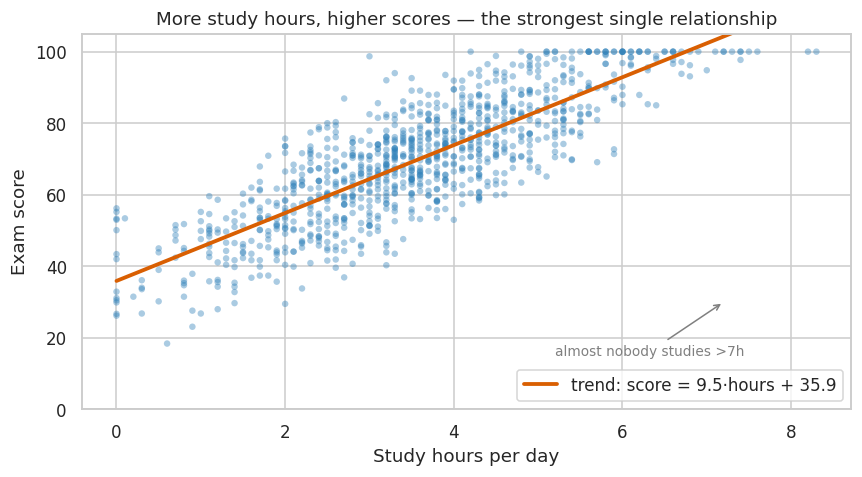

In [39]:
fig, ax = plt.subplots(figsize=(8, 4.5))

ax.scatter(merged["study_hours_per_day"], merged["exam_score"],
           alpha=0.4, s=18, color="#2c7fb8", edgecolor="none")

# Add a simple trend line (least squares fit of degree 1)
m, b = np.polyfit(merged["study_hours_per_day"], merged["exam_score"], deg=1)
xs = np.linspace(merged["study_hours_per_day"].min(),
                 merged["study_hours_per_day"].max(), 100)
ax.plot(xs, m * xs + b, color="#d95f02", linewidth=2.5,
        label=f"trend: score = {m:.1f}·hours + {b:.1f}")

ax.set_xlabel("Study hours per day")
ax.set_ylabel("Exam score")
ax.set_title("More study hours, higher scores — the strongest single relationship")
ax.legend(loc="lower right")
ax.set_ylim(0, 105)
ax.annotate("almost nobody studies >7h",
            xy=(7.2, 30), xytext=(5.2, 15),
            arrowprops=dict(arrowstyle="->", color="gray"), color="gray", fontsize=9)

fig.tight_layout()
plt.show()

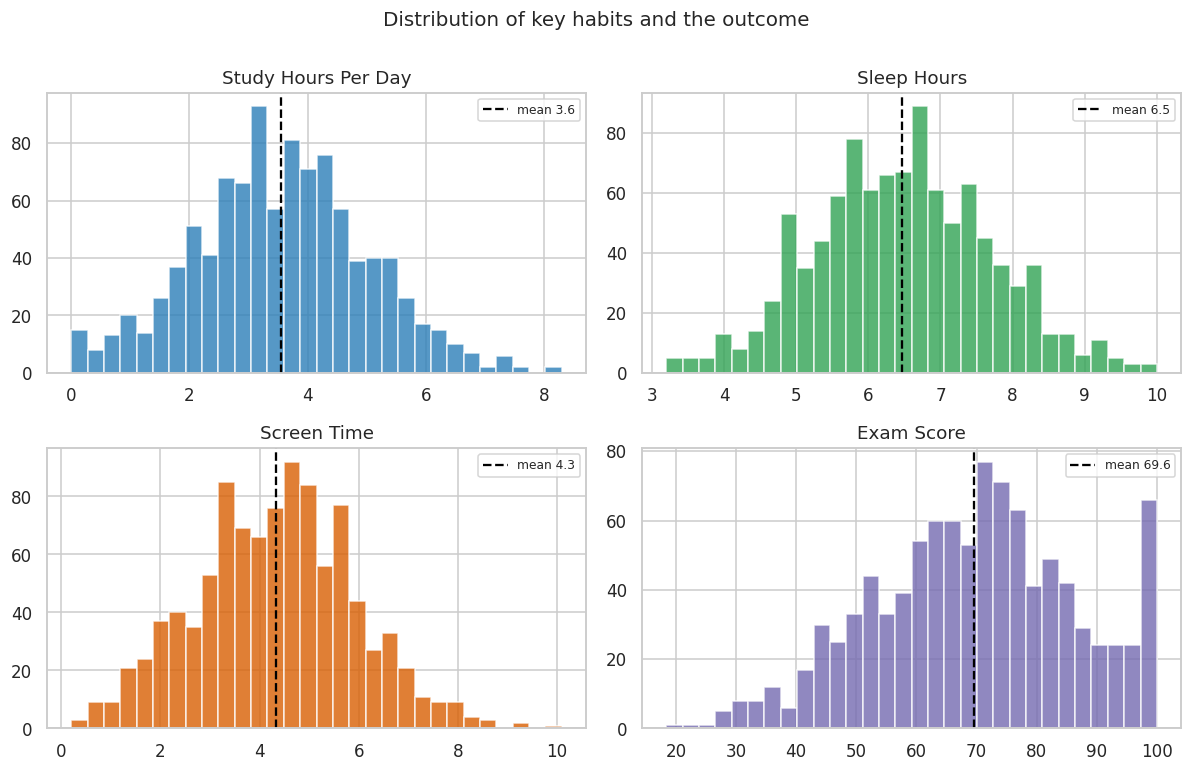

In [40]:
# Subplots: a 2x2 grid of distributions
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
cols = ["study_hours_per_day", "sleep_hours", "screen_time", "exam_score"]
colors = ["#2c7fb8", "#31a354", "#d95f02", "#756bb1"]

for ax, col, colr in zip(axes.flat, cols, colors):
    ax.hist(merged[col], bins=30, color=colr, alpha=0.8, edgecolor="white")
    ax.axvline(merged[col].mean(), color="black", linestyle="--", linewidth=1.5,
               label=f"mean {merged[col].mean():.1f}")
    ax.set_title(col.replace("_", " ").title())
    ax.legend(fontsize=8)

fig.suptitle("Distribution of key habits and the outcome", fontsize=13, y=1.00)
fig.tight_layout()
plt.show()

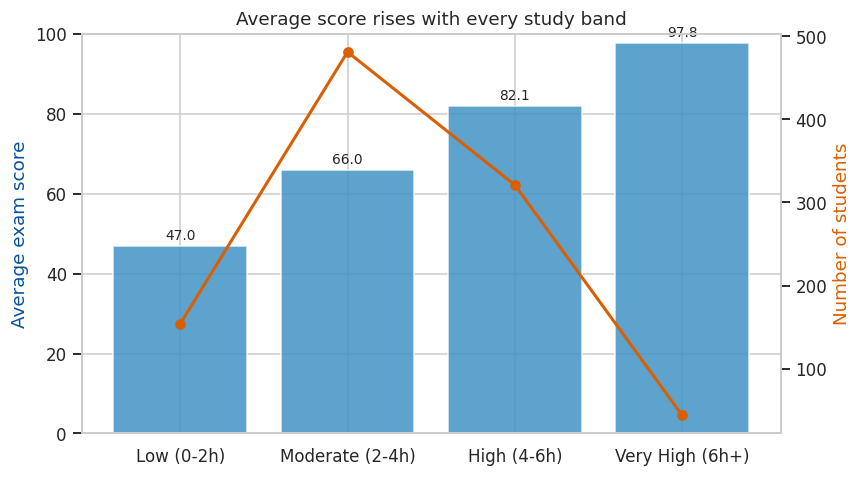

figure saved as study_band_scores.png


In [41]:
# Bar chart + line on twin axes, and saving the figure to disk
band_stats = merged.groupby("study_band", observed=True).agg(
    avg_score=("exam_score", "mean"), n=("student_id", "count"))

fig, ax1 = plt.subplots(figsize=(8, 4.5))
bars = ax1.bar(band_stats.index.astype(str), band_stats["avg_score"],
               color="#4292c6", alpha=0.85)
ax1.set_ylabel("Average exam score", color="#08519c")
ax1.set_ylim(0, 100)
ax1.bar_label(bars, fmt="%.1f", padding=2, fontsize=9)

ax2 = ax1.twinx()                       # a second y-axis sharing the same x
ax2.plot(band_stats.index.astype(str), band_stats["n"],
         color="#d95f02", marker="o", linewidth=2, label="students")
ax2.set_ylabel("Number of students", color="#d95f02")
ax2.grid(False)

ax1.set_title("Average score rises with every study band")
fig.tight_layout()
fig.savefig("study_band_scores.png", dpi=150, bbox_inches="tight")
plt.show()
print("figure saved as study_band_scores.png")

## D2 · Seaborn — statistical plots in one line

Seaborn takes `data=`, and column *names* for `x=`, `y=`, `hue=`. It computes the
statistics (means, confidence intervals, KDEs) for you.

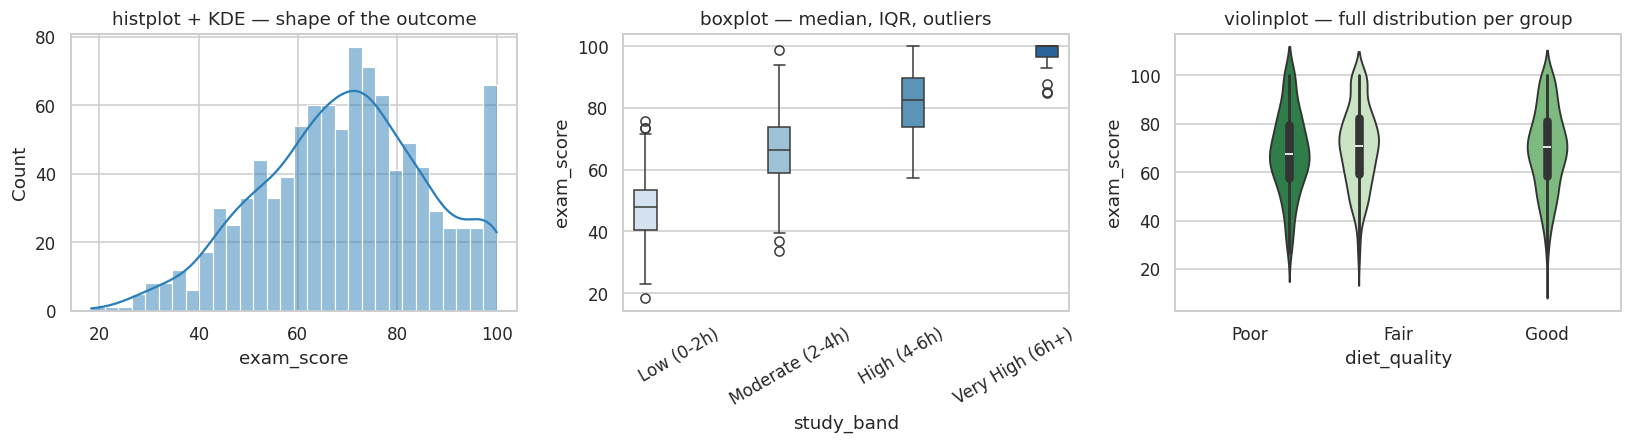

In [42]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

sns.histplot(data=merged, x="exam_score", kde=True, bins=30,
             color="#2c7fb8", ax=axes[0])
axes[0].set_title("histplot + KDE — shape of the outcome")

sns.boxplot(data=merged, x="study_band", y="exam_score", ax=axes[1],
            hue="study_band", legend=False, palette="Blues")
axes[1].set_title("boxplot — median, IQR, outliers")
axes[1].tick_params(axis="x", rotation=30)

sns.violinplot(data=merged, x="diet_quality", y="exam_score", ax=axes[2],
               hue="diet_quality", legend=False, palette="Greens")
axes[2].set_title("violinplot — full distribution per group")

fig.tight_layout()
plt.show()

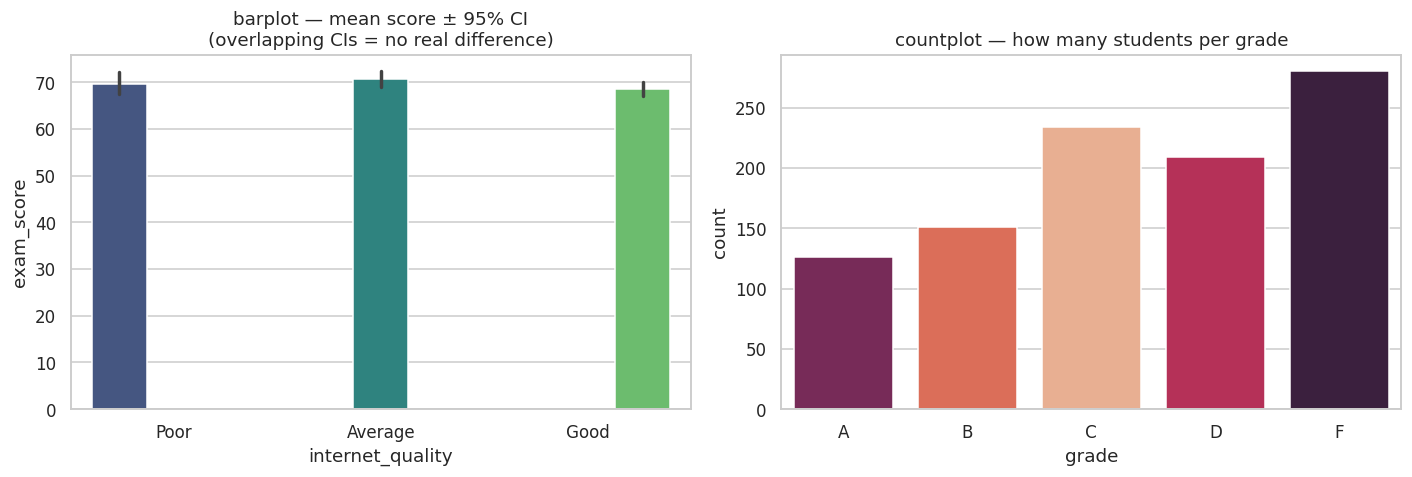

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# barplot shows the MEAN with a bootstrapped 95% confidence interval
sns.barplot(data=merged, x="internet_quality", y="exam_score",
            ax=axes[0], hue="internet_quality", legend=False, palette="viridis")
axes[0].set_title("barplot — mean score ± 95% CI\n(overlapping CIs = no real difference)")

# countplot is a bar chart of frequencies
sns.countplot(data=merged, x="grade", order=["A", "B", "C", "D", "F"],
              ax=axes[1], hue="grade", legend=False, palette="rocket")
axes[1].set_title("countplot — how many students per grade")

fig.tight_layout()
plt.show()

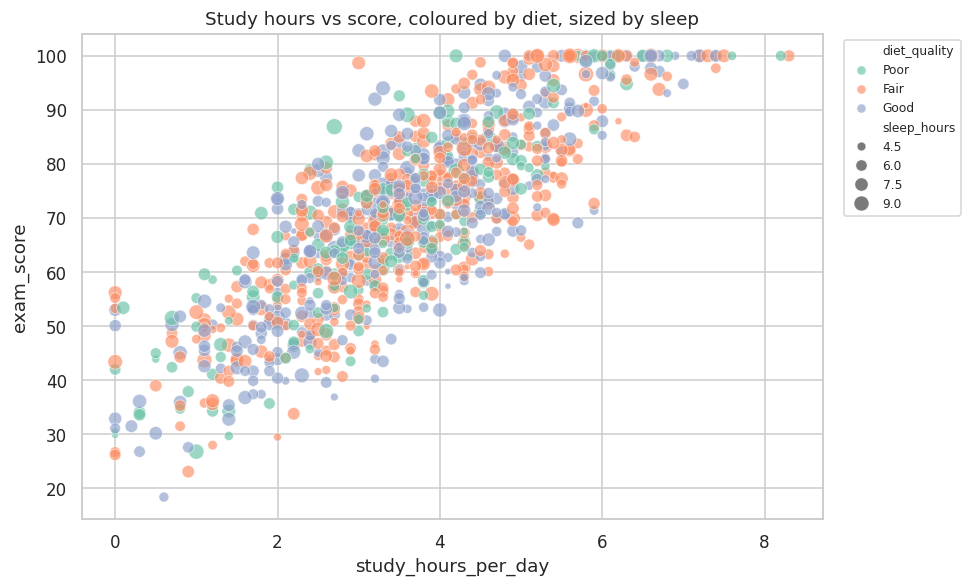

In [44]:
# scatterplot with hue + size encodes four variables at once
fig, ax = plt.subplots(figsize=(9, 5.5))
sns.scatterplot(data=merged, x="study_hours_per_day", y="exam_score",
                hue="diet_quality", size="sleep_hours", sizes=(15, 110),
                alpha=0.65, palette="Set2", ax=ax)
ax.set_title("Study hours vs score, coloured by diet, sized by sleep")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
fig.tight_layout()
plt.show()

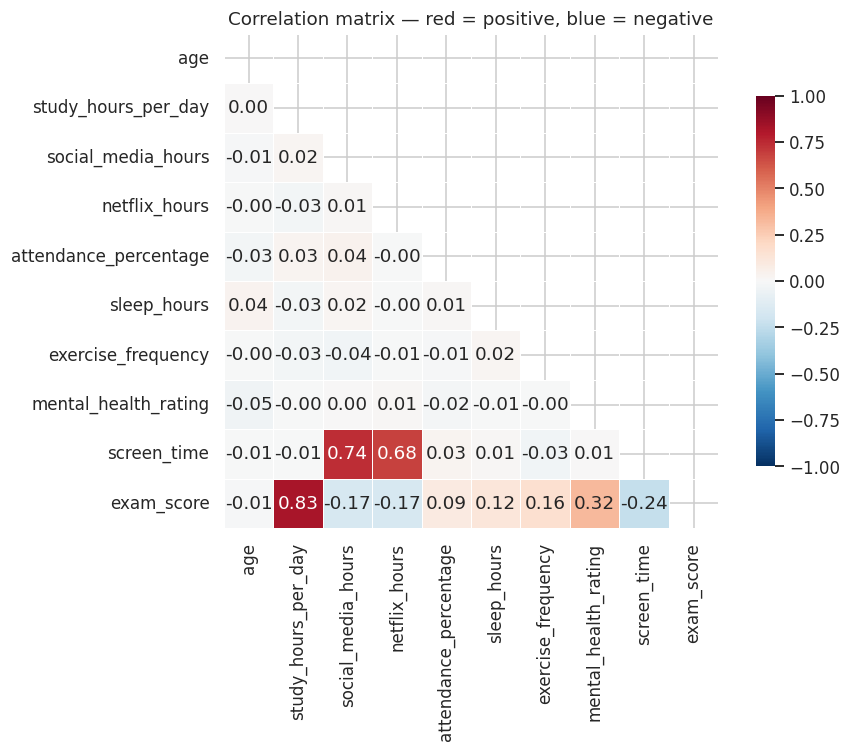

Strongest correlations with exam_score:
study_hours_per_day      0.825
mental_health_rating     0.322
screen_time             -0.238
netflix_hours           -0.172
social_media_hours      -0.167
exercise_frequency       0.160
sleep_hours              0.122
attendance_percentage    0.090
age                     -0.009
Name: exam_score, dtype: float64


In [45]:
# Correlation heatmap — the single most useful EDA plot
num_cols = ["age", "study_hours_per_day", "social_media_hours", "netflix_hours",
            "attendance_percentage", "sleep_hours", "exercise_frequency",
            "mental_health_rating", "screen_time", "exam_score"]
corr = merged[num_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))     # hide the mirrored upper triangle
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, square=True,
            linewidths=0.5, cbar_kws={"shrink": 0.75}, ax=ax)
ax.set_title("Correlation matrix — red = positive, blue = negative")
fig.tight_layout()
plt.show()

print("Strongest correlations with exam_score:")
print(corr["exam_score"].drop("exam_score").sort_values(key=abs, ascending=False).round(3))

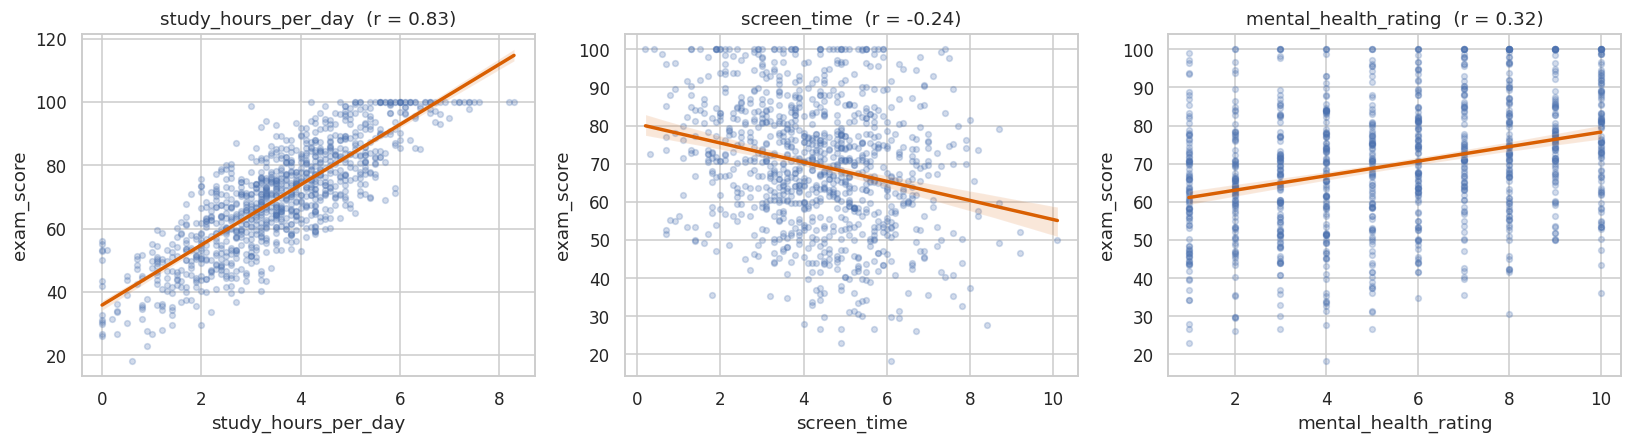

In [46]:
# regplot — scatter + fitted regression line + CI band
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, col in zip(axes, ["study_hours_per_day", "screen_time", "mental_health_rating"]):
    sns.regplot(data=merged, x=col, y="exam_score", ax=ax,
                scatter_kws=dict(alpha=0.25, s=14), line_kws=dict(color="#d95f02"))
    r = merged[col].corr(merged["exam_score"])
    ax.set_title(f"{col}  (r = {r:.2f})")
fig.tight_layout()
plt.show()

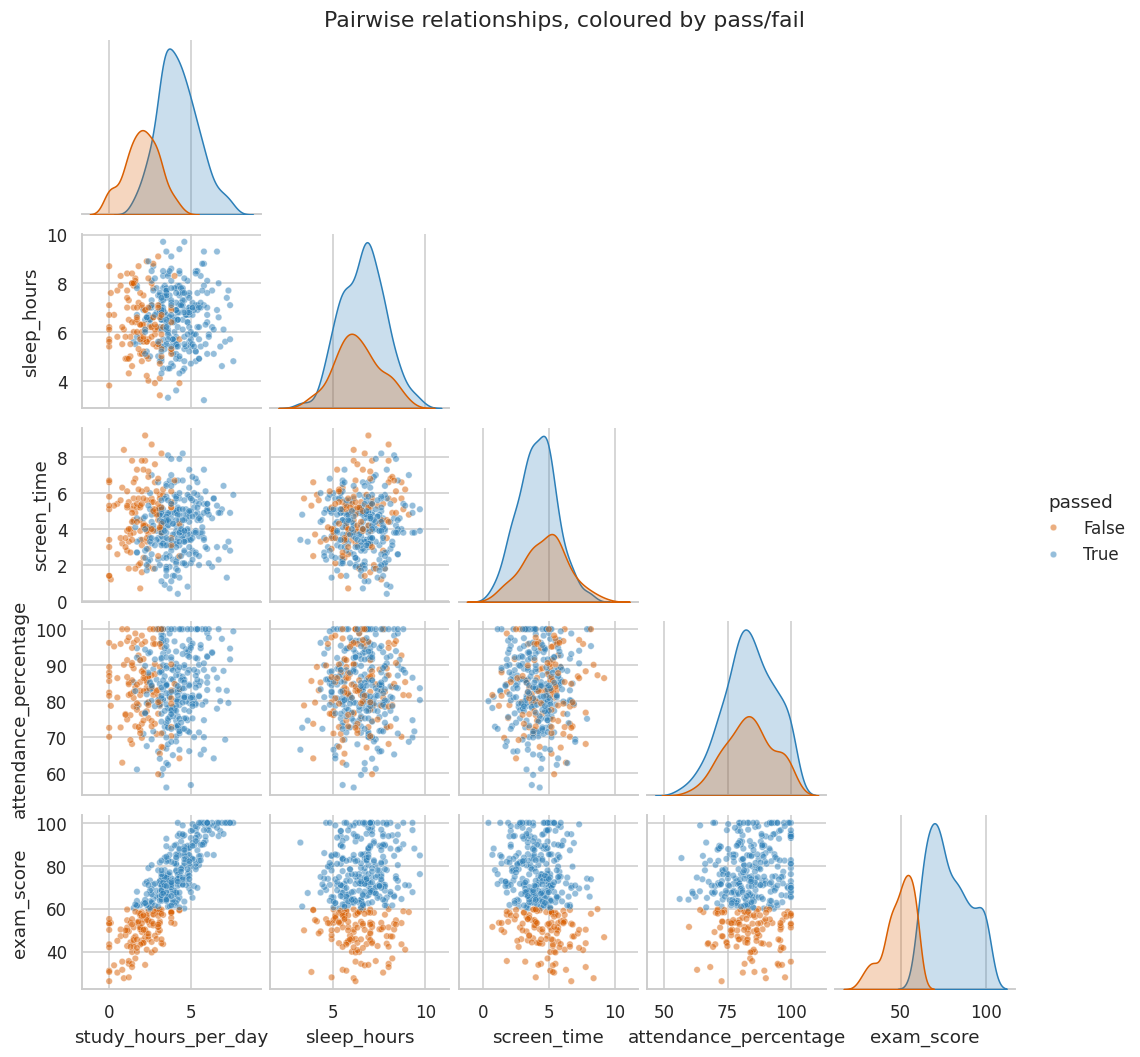

In [47]:
# pairplot — every pairwise scatter + diagonal distributions.
# Powerful but expensive: keep it to 4-5 columns.
subset = merged[["study_hours_per_day", "sleep_hours", "screen_time",
                 "attendance_percentage", "exam_score", "passed"]].sample(400, random_state=0)
g = sns.pairplot(subset, hue="passed", palette={True: "#2c7fb8", False: "#d95f02"},
                 corner=True, plot_kws=dict(alpha=0.5, s=18), height=1.9)
g.figure.suptitle("Pairwise relationships, coloured by pass/fail", y=1.01)
plt.show()

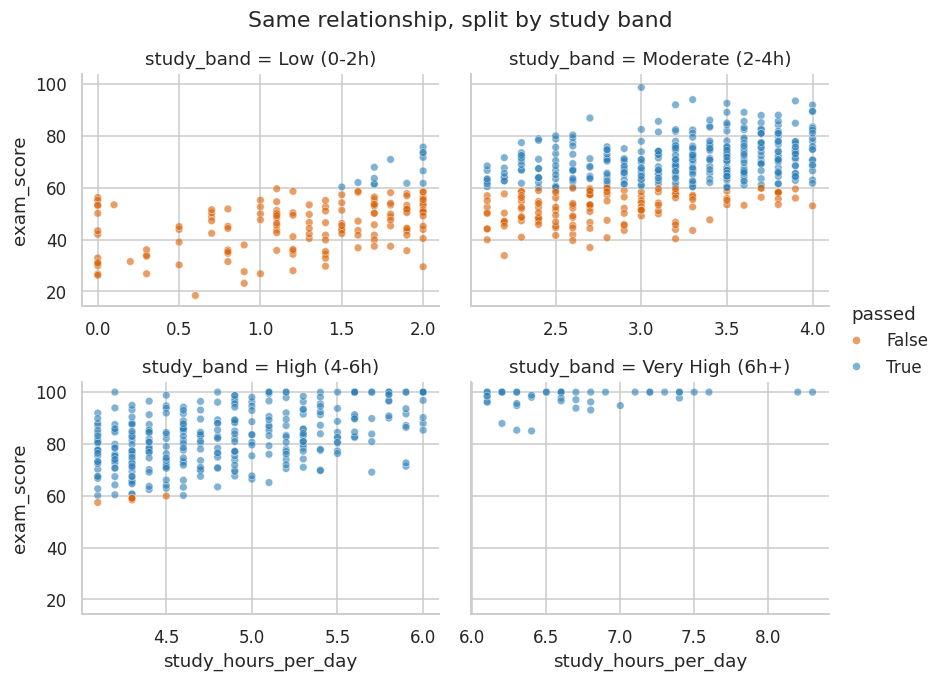

In [48]:
# FacetGrid / relplot — one small panel per category ("small multiples")
g = sns.relplot(data=merged, x="study_hours_per_day", y="exam_score",
                col="study_band", col_wrap=2, hue="passed",
                palette={True: "#2c7fb8", False: "#d95f02"},
                alpha=0.6, s=25, height=3, aspect=1.3,
                facet_kws=dict(sharex=False))
g.figure.suptitle("Same relationship, split by study band", y=1.03)
plt.show()

---
## Mini-challenge

Try these before moving on to Weeks 5–6. Every one is doable with what is above.

1. Write a function `habit_score(row)` that combines study hours, sleep and screen time
   into a single 0–100 "healthy habits" index, apply it to `merged`, and check its
   correlation with `exam_score`.
2. Use `groupby` + `agg` to find, for each `department`, the pass rate and the average
   `screen_time` of students who **failed**.
3. Build a `DatasetProfiler` subclass called `ReportProfiler` that adds a `top_features(n)`
   method returning the `n` columns most correlated with the target.
4. Recreate the correlation heatmap using only Matplotlib (`ax.imshow` + `ax.text`).
5. Vectorise the `risk_label` function fully with `np.select` and time both versions.

In [49]:
# --- your workspace for the mini-challenge ---

---
## Recap

| You learned | Key API |
|---|---|
| Functions with defaults, `*args`, `**kwargs`, type hints | `def f(a, b=1, *args, **kwargs) -> T:` |
| Comprehensions for lists, dicts, sets | `[x for x in it if cond]` |
| Classes, properties, inheritance | `__init__`, `self`, `@property`, `super()` |
| NumPy arrays, masks, fancy indexing | `arr[mask]`, `np.where`, `arr[:, 0]` |
| Broadcasting | shapes align from the right; `[:, np.newaxis]` |
| Vectorisation | `arr ** 2` instead of a Python loop (50–200× faster) |
| Pandas selection | `.loc` (labels) vs `.iloc` (positions) |
| Cleaning | `isna`, `fillna`, `Categorical`, `duplicated` |
| Feature engineering | `np.select`, `pd.cut`, `pd.qcut`, `.map`, `.apply` |
| Split-apply-combine | `groupby().agg()`, `.transform()`, `pivot_table`, `crosstab` |
| Combining tables | `pd.merge(how=...)`, `pd.concat` |
| Matplotlib | `fig, ax = plt.subplots()`, `ax.scatter/hist/bar`, `twinx`, `savefig` |
| Seaborn | `histplot`, `boxplot`, `violinplot`, `barplot`, `heatmap`, `regplot`, `pairplot`, `relplot` |

**Findings so far:** study hours is by far the strongest predictor of exam score
(r ≈ 0.83), with mental health rating a distant second (r ≈ 0.32). Social media and Netflix
hours pull the score down (r ≈ −0.17 each); sleep, exercise and attendance have only a mild
effect, and age has none at all. Weeks 7–8 turn these observations into actual models.

**Next:** `week05_06_linear_algebra_calculus.ipynb` — the maths that makes those
models work.